In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [2]:
np.random.seed(1)

In [3]:
# Simulating a well-behaved mixed-effects dataset.

n_participants = 40

memory_loads = [2, 4, 6, 8]

n_trials = 15

grand_mean = 600

participant_sd = 50

trial_sd = 25

population_slope = 18

participant_intercepts = np.random.normal(
    loc=grand_mean,
    scale=participant_sd,
    size=n_participants
)

participant = []

memory_load = []

reaction_time = []

for i in range(n_participants):

    baseline = participant_intercepts[i]

    for load in memory_loads:

        rt = np.random.normal(
            loc=baseline + population_slope * load,
            scale=trial_sd,
            size=n_trials
        )

        participant.extend([i + 1] * n_trials)

        memory_load.extend([load] * n_trials)

        reaction_time.extend(rt)

data = pd.DataFrame({
    "participant": participant,
    "memory_load": memory_load,
    "reaction_time": reaction_time
})

In [4]:
# Fitting the correct mixed-effects model.

model = smf.mixedlm(
    "reaction_time ~ memory_load",
    data=data,
    groups=data["participant"]
).fit()

print(model.summary())

           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: reaction_time
No. Observations: 2400    Method:             REML         
No. Groups:       40      Scale:              632.6161     
Min. group size:  60      Log-Likelihood:     -11250.9026  
Max. group size:  60      Converged:          Yes          
Mean group size:  60.0                                     
-----------------------------------------------------------
              Coef.   Std.Err.   z    P>|z|  [0.025  0.975]
-----------------------------------------------------------
Intercept     596.009    7.924 75.214 0.000 580.478 611.540
memory_load    18.043    0.230 78.581 0.000  17.592  18.493
Group Var    2448.406   22.320                             



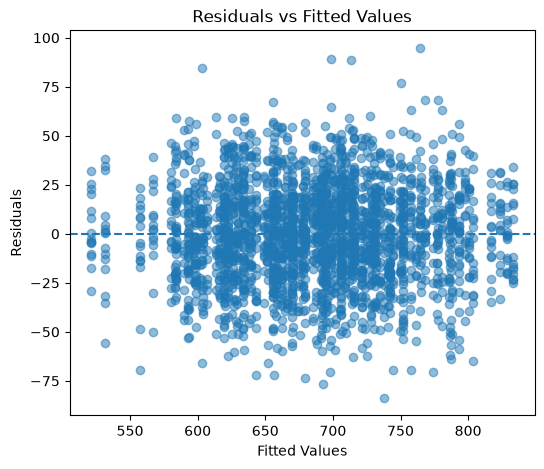

In [5]:
# Predictions and Residuals

data["fitted"] = model.fittedvalues

data["residuals"] = model.resid

# Residual Diagnostics

plt.figure(figsize=(6, 5))

plt.scatter(
    data["fitted"],
    data["residuals"],
    alpha=0.5
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Fitted Values")

plt.ylabel("Residuals")

plt.title("Residuals vs Fitted Values")

plt.show()

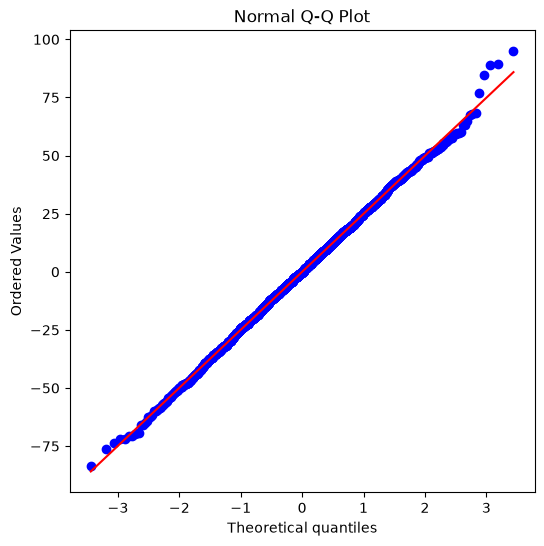

In [6]:
# QQ Plot

plt.figure(figsize=(6, 6))

stats.probplot(
    data["residuals"],
    dist="norm",
    plot=plt
)

plt.title("Normal Q-Q Plot")

plt.show()

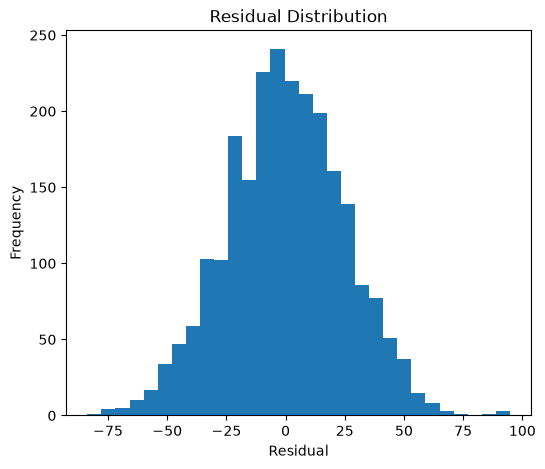

In [7]:
# Histogram of Residuals

plt.figure(figsize=(6, 5))

plt.hist(
    data["residuals"],
    bins=30
)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Residual Distribution")

plt.show()

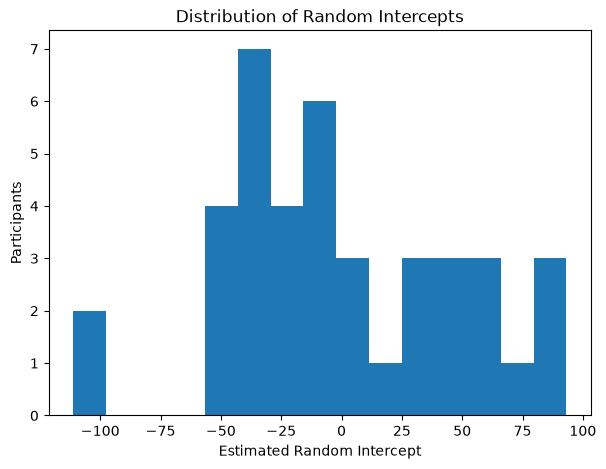

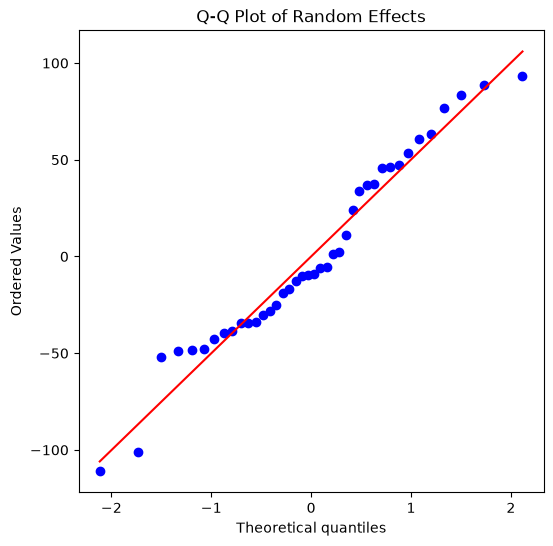

In [8]:
# Random-Effect Diagnostics

random_effects = model.random_effects

random_intercepts = [
    random_effects[key].iloc[0]
    for key in random_effects
]

plt.figure(figsize=(7, 5))

plt.hist(
    random_intercepts,
    bins=15
)

plt.xlabel("Estimated Random Intercept")
plt.ylabel("Participants")
plt.title("Distribution of Random Intercepts")

plt.show()

plt.figure(figsize=(6, 6))

stats.probplot(
    random_intercepts,
    dist="norm",
    plot=plt
)

plt.title("Q-Q Plot of Random Effects")

plt.show()

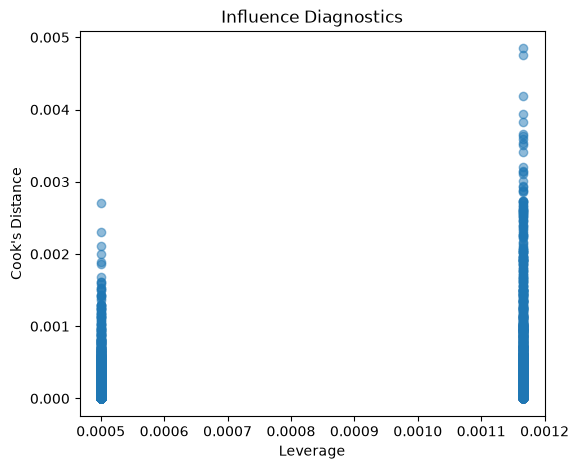

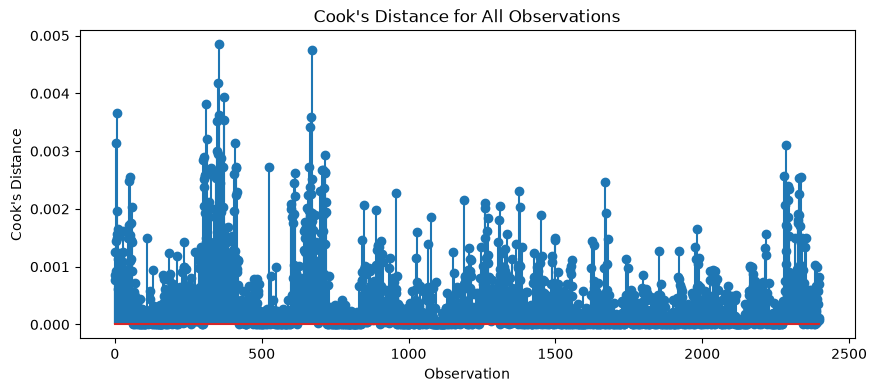

In [9]:
# Influence, Leverage and Cook's Distance

ols_model = smf.ols(
    "reaction_time ~ memory_load",
    data=data
).fit()

influence = ols_model.get_influence()

summary_frame = influence.summary_frame()

data["leverage"] = summary_frame["hat_diag"]

data["cooks_distance"] = summary_frame["cooks_d"]

plt.figure(figsize=(6, 5))

plt.scatter(
    data["leverage"],
    data["cooks_distance"],
    alpha=0.5
)

plt.xlabel("Leverage")
plt.ylabel("Cook's Distance")
plt.title("Influence Diagnostics")

plt.show()

plt.figure(figsize=(10, 4))

plt.stem(
    np.arange(len(data)),
    data["cooks_distance"]
)

plt.xlabel("Observation")
plt.ylabel("Cook's Distance")
plt.title("Cook's Distance for All Observations")

plt.show()

In [10]:
# Summary statistics

print("Dataset\n", data.head())

print("\nResidual summary\n")

print(data["residuals"].describe())

print("\nRandom intercept summary\n")

print(pd.Series(random_intercepts).describe())

print("\nMaximum Cook's Distance:")

print(data["cooks_distance"].max())

print("\nMaximum Leverage:")

print(data["leverage"].max())

Dataset
    participant  memory_load  reaction_time      fitted  residuals  leverage  \
0            1            2     712.421379  720.725666  -8.304287  0.001167   
1            1            2     695.026544  720.725666 -25.699122  0.001167   
2            1            2     698.538311  720.725666 -22.187355  0.001167   
3            1            2     759.528633  720.725666  38.802967  0.001167   
4            1            2     718.487462  720.725666  -2.238204  0.001167   

   cooks_distance  
0        0.001248  
1        0.000766  
2        0.000854  
3        0.003142  
4        0.001444  

Residual summary

count    2.400000e+03
mean    -1.242952e-12
std      2.494216e+01
min     -8.373237e+01
25%     -1.689786e+01
50%     -1.317080e-01
75%      1.697962e+01
max      9.479006e+01
Name: residuals, dtype: float64

Random intercept summary

count    4.000000e+01
mean    -2.038540e-10
std      4.937733e+01
min     -1.111614e+02
25%     -3.444262e+01
50%     -9.355583e+00
75%      3

In [11]:
# Singular Fits and Boundary Fits

print("Singular Fits and Boundary Fits")

# Simulating a very small dataset with an unnecessarily complex random-effects structure.

n_participants = 8

n_sessions = 5

participant = []

session = []

reaction_time = []

participant_intercepts = np.random.normal(
    600,
    30,
    n_participants
)

participant_slopes = np.random.normal(
    -15,
    0.2,
    n_participants
)

for i in range(n_participants):

    for s in range(1, n_sessions + 1):

        rt = np.random.normal(
            participant_intercepts[i] +
            participant_slopes[i] * s,
            15
        )

        participant.append(i + 1)

        session.append(s)

        reaction_time.append(rt)

singular_data = pd.DataFrame({
    "participant": participant,
    "session": session,
    "reaction_time": reaction_time
})

try:

    singular_model = smf.mixedlm(
        "reaction_time ~ session",
        data=singular_data,
        groups=singular_data["participant"],
        re_formula="~session"
    ).fit()

    print(singular_model.summary())

except Exception as e:

    print(e)

Singular Fits and Boundary Fits


C:\Users\Erfan\miniforge3\envs\cog-modeling\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Erfan\miniforge3\envs\cog-modeling\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
C:\Users\Erfan\miniforge3\envs\cog-modeling\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Erfan\miniforge3\envs\cog-modeling\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(


              Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   reaction_time
No. Observations:    40        Method:               REML         
No. Groups:          8         Scale:                243.7060     
Min. group size:     5         Log-Likelihood:       -173.7530    
Max. group size:     5         Converged:            No           
Mean group size:     5.0                                          
------------------------------------------------------------------
                     Coef.   Std.Err.   z    P>|z|  [0.025  0.975]
------------------------------------------------------------------
Intercept            586.037   13.296 44.077 0.000 559.978 612.096
session              -12.413    1.905 -6.514 0.000 -16.147  -8.678
Group Var           1146.118   36.932                             
Group x session Cov  -29.098    3.799                             
session Var            4.676                                      



C:\Users\Erfan\miniforge3\envs\cog-modeling\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Erfan\miniforge3\envs\cog-modeling\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\Erfan\miniforge3\envs\cog-modeling\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 6.117483
  warnings.warn(msg, ConvergenceWarning)
C:\Users\Erfan\miniforge3\envs\cog-modeling\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


In [12]:
# Non-convergence

print("Non-convergence")

try:

    bad_model = smf.mixedlm(
        "reaction_time ~ session",
        data=singular_data,
        groups=singular_data["participant"],
        re_formula="~session"
    ).fit(
        method="cg",
        maxiter=5
    )

    print(bad_model.summary())

except Exception as e:

    print(e)

Non-convergence
              Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   reaction_time
No. Observations:   40        Method:               REML         
No. Groups:         8         Scale:                250.5344     
Min. group size:    5         Log-Likelihood:       -175.1901    
Max. group size:    5         Converged:            No           
Mean group size:    5.0                                          
-----------------------------------------------------------------
                     Coef.  Std.Err.   z    P>|z|  [0.025  0.975]
-----------------------------------------------------------------
Intercept           586.037   12.611 46.472 0.000 561.320 610.753
session             -12.413    2.032 -6.109 0.000 -16.395  -8.430
Group Var           996.620   31.405                             
Group x session Cov  71.743    3.173                             
session Var           7.976                                      



C:\Users\Erfan\miniforge3\envs\cog-modeling\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Erfan\miniforge3\envs\cog-modeling\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\Erfan\miniforge3\envs\cog-modeling\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 13.215322
  warnings.warn(msg, ConvergenceWarning)
C:\Users\Erfan\miniforge3\envs\cog-modeling\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


In [13]:
# Multicollinearity

print("Multicollinearity")

n = 500

x1 = np.random.normal(size=n)

x2 = x1 + np.random.normal(
    scale=0.02,
    size=n
)

y = 10 + 4 * x1 + np.random.normal(size=n)

multicol_data = pd.DataFrame({
    "x1": x1,
    "x2": x2,
    "y": y
})

multicol_model = smf.ols(
    "y ~ x1 + x2",
    data=multicol_data
).fit()

print(multicol_model.summary())

correlation = multicol_data[
    ["x1", "x2"]
].corr()

print("\nPredictor Correlation\n")

print(correlation)

Multicollinearity
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                     3622.
Date:                Sun, 19 Jul 2026   Prob (F-statistic):          4.74e-297
Time:                        17:05:35   Log-Likelihood:                -707.91
No. Observations:                 500   AIC:                             1422.
Df Residuals:                     497   BIC:                             1434.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      9.9761      0.045  

In [14]:
# Overparameterization

print("Overparameterization")

n = 80

over_data = pd.DataFrame({
    "y": np.random.normal(size=n)
})

for i in range(20):

    over_data[f"x{i}"] = np.random.normal(size=n)

formula = (
    "y ~ " +
    " + ".join(
        [f"x{i}" for i in range(20)]
    )
)

over_model = smf.ols(
    formula,
    data=over_data
).fit()

print(over_model.summary())

Overparameterization
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.202
Model:                            OLS   Adj. R-squared:                 -0.068
Method:                 Least Squares   F-statistic:                    0.7483
Date:                Sun, 19 Jul 2026   Prob (F-statistic):              0.760
Time:                        17:05:35   Log-Likelihood:                -95.892
No. Observations:                  80   AIC:                             233.8
Df Residuals:                      59   BIC:                             283.8
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.1148      0.12

In [15]:
# Fixing the problems

print("Fixing the Problems")

# Better mixed model

fixed_model = smf.mixedlm(
    "reaction_time ~ memory_load",
    data=data,
    groups=data["participant"]
).fit()

print("\nCorrect Mixed Model\n")

print(fixed_model.summary())

# Remove multicollinearity

reduced_model = smf.ols(
    "y ~ x1",
    data=multicol_data
).fit()

print("\nReduced Regression Model\n")

print(reduced_model.summary())

# Simpler regression

simple_formula = (
    "y ~ " +
    " + ".join(
        [f"x{i}" for i in range(5)]
    )
)

simple_model = smf.ols(
    simple_formula,
    data=over_data
).fit()

print("\nSimplified Regression Model\n")

print(simple_model.summary())

Fixing the Problems

Correct Mixed Model

           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: reaction_time
No. Observations: 2400    Method:             REML         
No. Groups:       40      Scale:              632.6161     
Min. group size:  60      Log-Likelihood:     -11250.9026  
Max. group size:  60      Converged:          Yes          
Mean group size:  60.0                                     
-----------------------------------------------------------
              Coef.   Std.Err.   z    P>|z|  [0.025  0.975]
-----------------------------------------------------------
Intercept     596.009    7.924 75.214 0.000 580.478 611.540
memory_load    18.043    0.230 78.581 0.000  17.592  18.493
Group Var    2448.406   22.320                             


Reduced Regression Model

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.936
Mod